In [22]:
import numpy as np
from scipy.stats import truncnorm, norm
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('data/krajbich_NatNeu_2010/data.csv')
df.head(10)

,,subject,trial,fix_num,event_duration,leftrating,rightrating,rt,choice,roi,computed_rt,num_fixations,rev_fix_num,temp,corr_fix_duration
0,0,10.0,1,1.0,98.0,4.0,2.0,3808.0,1.0,1.0,3820.0,7.0,7.0,350.28570,350.2857
1,1,10.0,1,2.0,426.0,4.0,2.0,3808.0,1.0,2.0,3820.0,7.0,6.0,450.35226,426.0000
2,2,10.0,1,3.0,319.0,4.0,2.0,3808.0,1.0,1.0,3820.0,7.0,5.0,385.79688,319.0000
3,3,10.0,1,4.0,259.0,4.0,2.0,3808.0,1.0,2.0,3820.0,7.0,4.0,486.14285,259.0000
4,4,10.0,1,5.0,1472.0,4.0,2.0,3808.0,1.0,1.0,3820.0,7.0,3.0,573.85710,1472.0000
5,5,10.0,1,6.0,382.0,4.0,2.0,3808.0,1.0,2.0,3820.0,7.0,2.0,535.12500,382.0000
6,6,10.0,1,7.0,217.0,4.0,2.0,3808.0,1.0,1.0,3820.0,7.0,1.0,647.33330,217.0000
7,7,10.0,2,1.0,299.0,3.0,2.0,1913.0,1.0,2.0,1936.0,4.0,4.0,350.28570,299.0000
8,8,10.0,2,2.0,397.0,3.0,2.0,1913.0,1.0,1.0,1936.0,4.0,3.0,450.35226,397.0000
9,9,10.0,2,3.0,499.0,3.0,2.0,1913.0,1.0,2.0,1936.0,4.0,2.0,385.79688,499.0000


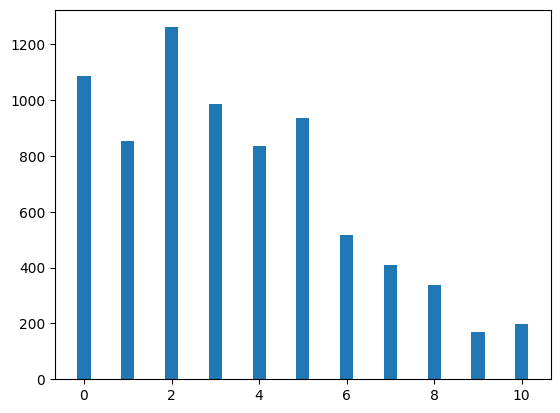

In [24]:
df_trial = df.groupby(['subject', 'trial']).agg({'leftrating': 'first', 'rightrating': 'first'}).reset_index()
ratings1 = np.array([df_trial['leftrating'], df_trial['rightrating']]).reshape(-1)
uniques, counts = np.unique(ratings1, return_counts = True)
plt.figure()
plt.bar(uniques, counts, width = 0.3)
plt.show()

In [32]:
def negative_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    a = (0 - mu) / sigma  # truncation point
    log_likelihood = truncnorm.logpdf(data, a = a, b = np.inf, loc = mu, scale = sigma)
    return -np.sum(log_likelihood)

# initial guesses: use naive mean/std as starting point
mu0 = np.mean(ratings1)
sigma0 = np.std(ratings1)
res = minimize(negative_log_likelihood, [mu0, sigma0], args = (ratings1,))

res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 16688.33586548335
        x: [ 8.717e-02  4.337e+00]
      nit: 12
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 4.951e-02 -2.026e-02]
            [-2.026e-02  9.492e-03]]
     nfev: 42
     njev: 14

In [28]:
df = pd.read_csv('data/krajbich_PNAS_2011/data.csv')
df.head(10)

,Unnamed: 0,trial,rating1,rating2,rating3,roirating,rt,chosenrating,subject,eventduration,fix_num,choice1,choice2,choice3,leftroi,middleroi,rightroi,num_fixations,rev_fix_num
0,1,1,1,7,3,7,1782,7,1,318,1,0,1,0,0,1,0,4,4
1,2,1,1,7,3,3,1782,7,1,160,2,0,1,0,0,0,1,4,3
2,3,1,1,7,3,1,1782,7,1,139,3,0,1,0,1,0,0,4,2
3,4,1,1,7,3,7,1782,7,1,818,4,0,1,0,0,1,0,4,1
4,5,2,7,3,2,3,1063,3,1,119,1,0,1,0,0,1,0,4,4
5,6,2,7,3,2,2,1063,3,1,179,2,0,1,0,0,0,1,4,3
6,7,2,7,3,2,7,1063,3,1,99,3,0,1,0,1,0,0,4,2
7,8,2,7,3,2,3,1063,3,1,160,4,0,1,0,0,1,0,4,1
8,9,3,3,1,2,3,1171,2,1,200,1,0,0,1,1,0,0,3,3
9,10,3,3,1,2,2,1171,2,1,279,2,0,0,1,0,0,1,3,2


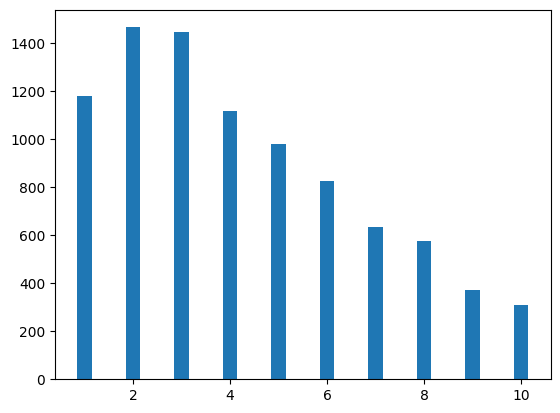

In [31]:
df_trial = df.groupby(['subject', 'trial']).agg({'rating1': 'first', 'rating2': 'first', 'rating3': 'first'}).reset_index()
ratings2 = np.array([df_trial['rating1'], df_trial['rating2'], df_trial['rating3']]).reshape(-1)
uniques, counts = np.unique(ratings2, return_counts = True)
plt.figure()
plt.bar(uniques, counts, width = 0.3)
plt.show()

In [33]:
def negative_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    a = (0 - mu) / sigma  # truncation point
    log_likelihood = truncnorm.logpdf(data, a = a, b = np.inf, loc = mu, scale = sigma)
    return -np.sum(log_likelihood)

# initial guesses: use naive mean/std as starting point
mu0 = np.mean(ratings2)
sigma0 = np.std(ratings2)
res = minimize(negative_log_likelihood, [mu0, sigma0], args = (ratings2,))

res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 20249.513956625593
        x: [ 3.607e+00  3.054e+00]
      nit: 15
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 5.623e-05  3.946e-06]
            [ 3.946e-06  8.360e-04]]
     nfev: 63
     njev: 21